# Active Learning

**Status: work in progress -- split out from notebook 06's Sections 6 and 7 on 2026-09-13, not yet runnable standalone. Left with basic instructions for now.**

**Goal:** Two active-learning loops. **Part 1** scores the classifier's uncertainty on images outside its training set, exports a review queue, applies human corrections, and retrains -- the loop notebook 06 used for one real round (see notebook 06's "Training history" paragraph) before later rounds redesigned the training set directly via full annotation passes instead. **Part 2** does the analogous thing for the segmenters: scores mask uncertainty on images the classifier is already confident about, and prioritizes those for mask annotation in Label Studio.

**Known issue -- fix before relying on this again:** the pool-scoring cell below only scans `data/img/annotation_sample/` and `data/img/annotation_sample_closed/` (`IMG_DIRS`, ~391 images combined) for candidates outside the training set -- not the full ~9,153-image catalog in `data/img/original_clean/`. Those staging folders are themselves built by notebook 03_a's oversampling strategies, so this pool has never actually included the ~8,760 catalog images the classifier has never been scored against. "0 images left in the pool" (the current state, as of this split) means the staging area is fully used up, not that the model has been checked against the rest of the catalog. Fix: point the pool scan at `original_clean/` (minus whatever's already in `train_df`/`val_df`) instead of `IMG_DIRS`.

**Not yet self-contained:** the cells below still assume `train_df`, `val_df`, `clf`, `CLASSES`, `DEVICE`, `IMG_DIRS`, `CLF_THRESHOLD`, `val_tf`, `run_epoch`, `build_classifier`, `class_weights`, `clf_ckpt`, `labels_df`, and (for Step 3's routing comparison) the trained segmenters (`seg`, `seg_other`, `seg_swatch`, `seg_lips`) and their extraction helpers already exist in memory from notebook 06. Needs a setup cell that reloads the classifier checkpoint and `labels.csv` (and the segmenter checkpoints, for Step 3) so this notebook can run on its own, top to bottom.

**Next planned use:** find more `lips` product images to annotate (currently the thinnest class) once the full-catalog pool scan above is wired up.

**Inputs:** `models/resnet18_classifier.pth`, `models/unet_segmenter*.pth` / `unet_swatch.pth` / `unet_lips.pth`, `data/annotations/labels.csv`, `data/annotations/masks/`, `data/img/original_clean/` (once the full-catalog fix lands)

**Outputs:** `data/annotations/active_learning_queue.csv`, `data/annotations/active_learning_seg_queue.csv`, `models/resnet18_classifier_al.pth`

## Diagnosing Stage 1 Misclassification → Active Learning for the Classifier

The outliers in Section 5 point to a Stage 1 problem: `closed`-container images are being misclassified as `bullet` or `liquid`, which routes them through the wrong U-Net and produces a nonsense color prediction.

**Step 1** surfaces this by scoring classifier uncertainty on images outside the training set. Low-confidence predictions — especially images the model splits between `bullet`/`liquid` and `closed` — reveal the misclassification pattern.

**Step 2** uses those images as an annotation queue: review, correct the label where wrong, and retrain Stage 1 with the expanded dataset.

In [33]:
# ── Find images outside classifier training/val sets ────────────────────────
clf_known = set(train_df['img_name_disk'].dropna()) | set(val_df['img_name_disk'].dropna())

all_on_disk = {}
for d in IMG_DIRS:
    for fname in os.listdir(d):
        if fname not in all_on_disk:
            all_on_disk[fname] = os.path.join(d, fname)

pool_candidates = [
    {'img_name': name, 'img_path': path}
    for name, path in all_on_disk.items()
    if name not in clf_known
]
print(f'Pool: {len(pool_candidates)} images outside classifier training/val sets')

# ── Score classifier uncertainty and record class probabilities ──────────────
def score_clf_uncertainty(model, img_path, device):
    """Returns (predicted_class, confidence, full softmax prob array)."""
    img = Image.open(img_path).convert('RGB')
    with torch.no_grad():
        probs = torch.softmax(
            model(val_tf(img).unsqueeze(0).to(device)), dim=1
        ).squeeze().cpu().numpy()
    return CLASSES[probs.argmax()], float(probs.max()), probs

clf.eval()
scored = []
for item in pool_candidates:
    try:
        pred_label, conf, probs = score_clf_uncertainty(clf, item['img_path'], DEVICE)
        scored.append({
            **item,
            'pred_label':  pred_label,
            'confidence':  conf,
            'uncertainty': 1 - conf,
            **{f'p_{c}': float(p) for c, p in zip(CLASSES, probs)},
        })
    except Exception:
        continue

_pool_cols = ['img_name', 'img_path', 'pred_label', 'confidence', 'uncertainty'] + [f'p_{c}' for c in CLASSES]
pool_clf_df = pd.DataFrame(scored, columns=_pool_cols).sort_values('uncertainty', ascending=False).reset_index(drop=True)
if pool_clf_df.empty:
    print('\nNo images left in the pool -- everything on disk is already in the classifier training/val set.')
else:
    print(f'\nTop 10 most uncertain classifier predictions:')
    print(pool_clf_df[['img_name', 'pred_label', 'confidence']].head(10).to_string(index=False))


Pool: 0 images outside classifier training/val sets

No images left in the pool -- everything on disk is already in the classifier training/val set.


In [34]:
n_show = min(8, len(pool_clf_df))
if n_show == 0:
    print('Pool is empty — all images in IMG_DIRS are already in the classifier training/val sets.')
else:
    top = pool_clf_df.head(n_show).reset_index(drop=True)
    ncols = 4
    nrows = int(np.ceil(n_show / ncols))
    fig, axes = plt.subplots(nrows * 2, ncols, figsize=(ncols * 3.5, nrows * 5))
    axes = axes.reshape(nrows * 2, ncols)

    for i, row in top.iterrows():
        r, c = (i // ncols) * 2, i % ncols
        img = np.array(Image.open(row['img_path']).convert('RGB'))
        axes[r, c].imshow(img)
        axes[r, c].set_title(
            f"pred: {row['pred_label']}\nconf={row['confidence']:.2f}", fontsize=7
        )
        axes[r, c].axis('off')

        probs = [row[f'p_{cls}'] for cls in CLASSES]
        bar_colors = ['#c97aa0' if CLASSES[j] == row['pred_label'] else '#bdc3c7'
                      for j in range(len(CLASSES))]
        axes[r+1, c].barh(CLASSES, probs, color=bar_colors)
        axes[r+1, c].set_xlim(0, 1)
        axes[r+1, c].axvline(0.5, color='gray', linestyle='--', linewidth=0.8)
        axes[r+1, c].tick_params(labelsize=6)
        axes[r+1, c].set_xlabel('probability', fontsize=6)

    for j in range(n_show, nrows * ncols):
        r, c = (j // ncols) * 2, j % ncols
        axes[r, c].axis('off')
        axes[r+1, c].axis('off')

    plt.suptitle(
        'Most uncertain classifier predictions — look for closed containers misclassified as bullet/liquid',
        fontsize=9
    )
    plt.tight_layout()
    plt.show()


Pool is empty — all images in IMG_DIRS are already in the classifier training/val sets.


In [35]:
export_path = os.path.join(ANN_DIR, 'active_learning_queue.csv')
pool_clf_df[['img_name', 'img_path', 'pred_label', 'confidence', 'uncertainty']].to_csv(export_path, index=False)
print(f'Exported {len(pool_clf_df)} candidates → {export_path}')
print('Review these images and add a "correct_label" column where the prediction is wrong.')


Exported 0 candidates → /Users/connie/dev/lipstick_color_extraction/data/annotations/active_learning_queue.csv
Review these images and add a "correct_label" column where the prediction is wrong.


### Step 2: Correct labels and retrain Stage 1

1. Open `data/annotations/active_learning_queue.csv`: prioritize images with the lowest confidence
2. Add a `correct_label` column with the true container type: `bullet`, `liquid`, `swatch`, or `closed`
3. Run the retrain cell below: it merges the corrected labels with the existing training set, recalculates class weights, and retrains Stage 1

No mask drawing needed: this is label correction only.

In [36]:
NEW_LABELS = os.path.join(ANN_DIR, 'active_learning_queue.csv')

_queue = pd.read_csv(NEW_LABELS) if os.path.exists(NEW_LABELS) else None
_has_corrections = _queue is not None and 'correct_label' in _queue.columns and _queue['correct_label'].notna().any()

if not _has_corrections:
    print('No corrected labels yet in the exported queue.')
    print(f'Review {NEW_LABELS}, add a "correct_label" column, and re-run this cell.')
    # No corrections to fine-tune on yet -- keep using the Phase 1 classifier and its val split
    # so downstream cells (evaluation, end-to-end comparison) still have something to run on.
    # Still write resnet18_classifier_al.pth: notebook 08 (and the archived old_notebooks/07_model_clustering.ipynb) load this file specifically, and
    # leaving a stale checkpoint there (wrong class order) is exactly the class-order-drift bug
    # this project has been burned by before.
    clf_al = clf
    val2   = val_df
    ckpt_al = os.path.join(MODELS_DIR, 'resnet18_classifier_al.pth')
    torch.save({'model_state_dict': clf_al.state_dict(), 'classes': CLASSES}, ckpt_al)
    print(f'Wrote {ckpt_al} as a copy of the Phase 1 classifier (no fine-tune happened yet).')
else:
    seed_everything()
    new_labels = (
        _queue
        .pipe(lambda d: d[d['correct_label'].notna()])
        .rename(columns={'correct_label': 'label'})
    )
    # img_name in this file is already the disk filename (from os.listdir)
    new_labels['img_name_disk'] = new_labels['img_name']
    # remap old label names to current label convention
    label_remap = {'other': 'closed', 'liquid_lipstick': 'liquid', 'bullet_lipstick': 'bullet'}
    new_labels['label'] = new_labels['label'].replace(label_remap)
    print(f'{len(new_labels)} corrected labels loaded')
    print(new_labels['label'].value_counts().to_string())

    # ── Expand dataset (original + corrected) ──────────────────────────────
    clf_all = pd.concat([
        labels_df[['img_name', 'img_name_disk', 'label']],
        new_labels[['img_name', 'img_name_disk', 'label']]
    ], ignore_index=True).drop_duplicates(subset='img_name_disk')

    counts2 = clf_all['label'].value_counts()
    total2  = len(clf_all)
    cw2 = torch.tensor(
        [total2 / (len(CLASSES) * counts2.get(c, 1)) for c in CLASSES], dtype=torch.float
    )
    print('Updated class weights:', {c: round(w, 3) for c, w in zip(CLASSES, cw2.tolist())})

    ann_closed2 = set(os.listdir(IMG_CLOSED))
    force2      = clf_all[clf_all['img_name_disk'].isin(ann_closed2)]
    to_split2   = clf_all[~clf_all['img_name_disk'].isin(ann_closed2) & clf_all['img_name_disk'].notna()]
    rest2, val2 = train_test_split(to_split2, test_size=0.2, stratify=to_split2['label'], random_state=42)
    train2      = pd.concat([force2, rest2]).reset_index(drop=True)
    print(f'Expanded — train: {len(train2)}  val: {len(val2)}  (was: {len(train_df)} / {len(val_df)})')

    # ── Fine-tune the existing classifier (don't retrain from scratch) ──────
    clf_al = build_classifier(num_classes=len(CLASSES), pretrained=False).to(DEVICE)
    clf_al.load_state_dict(torch.load(clf_ckpt, map_location=DEVICE)['model_state_dict'])

    ckpt_al   = os.path.join(MODELS_DIR, 'resnet18_classifier_al.pth')
    crit_al   = nn.CrossEntropyLoss(weight=cw2.to(DEVICE))
    tr_loader = DataLoader(ProductDataset(train2, train_tf), batch_size=32, shuffle=True, num_workers=0)
    va_loader = DataLoader(ProductDataset(val2,   val_tf),   batch_size=32, num_workers=0)

    for p in clf_al.parameters(): p.requires_grad = True
    opt_al   = torch.optim.Adam(clf_al.parameters(), lr=1e-5)
    sched_al = torch.optim.lr_scheduler.StepLR(opt_al, step_size=5, gamma=0.1)
    best_va  = 0.0
    print('Fine-tuning on expanded dataset (10 epochs, lr=1e-5)')
    for epoch in range(10):
        _, tr = run_epoch(clf_al, tr_loader, crit_al, opt_al, DEVICE)
        _, va = run_epoch(clf_al, va_loader, crit_al, opt_al, DEVICE, train=False)
        sched_al.step()
        print(f'  {epoch+1:2d}: train={tr:.3f}  val={va:.3f}')
        if va > best_va:
            best_va = va
            torch.save({'model_state_dict': clf_al.state_dict(), 'classes': CLASSES}, ckpt_al)

    print(f'\nBest val acc: {best_va:.3f}  →  {ckpt_al}')
    clf = clf_al
    print('Global `clf` updated to fine-tuned classifier.')


No corrected labels yet in the exported queue.
Review /Users/connie/dev/lipstick_color_extraction/data/annotations/active_learning_queue.csv, add a "correct_label" column, and re-run this cell.
Wrote /Users/connie/dev/lipstick_color_extraction/models/resnet18_classifier_al.pth as a copy of the Phase 1 classifier (no fine-tune happened yet).


                precision    recall  f1-score   support

        bullet       0.94      1.00      0.97        17
        closed       0.67      1.00      0.80         2
          lips       1.00      1.00      1.00         3
        liquid       1.00      1.00      1.00        11
        pencil       1.00      0.83      0.91         6
        swatch       0.96      1.00      0.98        23
unclassifiable       1.00      0.67      0.80         6

      accuracy                           0.96        68
     macro avg       0.94      0.93      0.92        68
  weighted avg       0.96      0.96      0.95        68



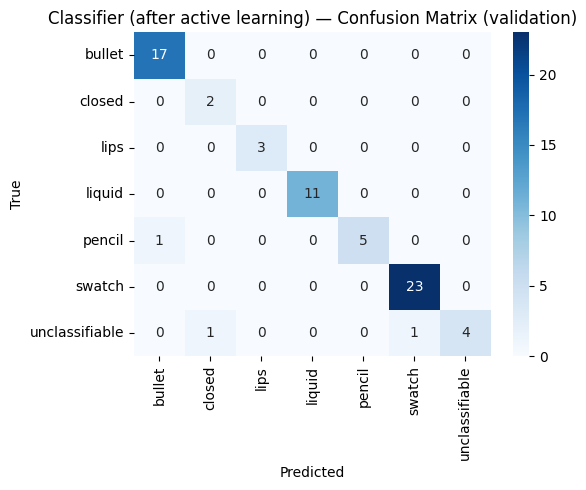

In [37]:
# Evaluate fine-tuned classifier on the expanded validation set
clf.eval()
preds_al, targets_al = [], []
with torch.no_grad():
    for x, y in DataLoader(ProductDataset(val2, val_tf), batch_size=32):
        preds_al.extend(clf(x.to(DEVICE)).argmax(1).cpu().tolist())
        targets_al.extend(y.tolist())

print(classification_report(targets_al, preds_al, target_names=CLASSES))

cm_al = confusion_matrix(targets_al, preds_al)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_al, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES,
            cmap='Blues', ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Classifier (after active learning) — Confusion Matrix (validation)')
plt.tight_layout()
plt.show()


### Step 3: What active learning actually improved

The routing accuracy table below compares the original classifier against whatever Step 2 produced. **In this run, Step 2 had no corrected labels to fine-tune on** (`active_learning_queue.csv` was freshly exported and hasn't been reviewed yet), so it fell back to the Phase 1 classifier unchanged -- "original" and "fine-tuned" are the same model here, which is why the table below shows identical numbers for every class. That's expected, not a bug: real gains only show up after the queue is reviewed (add a `correct_label` column) and this section is re-run.

When corrections do exist, the improvement isn't visible in this table either way, because `labels_df` is the classifier's own training/validation set -- the real test is generalization to images the model has never seen, which isn't captured by Delta E since pool labels are container type only, not color.

In [38]:
def run_e2e(classifier):
    """Run full pipeline using classifier predictions for routing."""
    classifier.eval(); seg.eval(); seg_other.eval(); seg_swatch.eval(); seg_lips.eval()
    rows = []
    for _, row in labels_df.iterrows():
        if pd.isna(row['img_name_disk']):
            continue
        img_path = find_image(row['img_name_disk'])
        if img_path is None:
            continue
        pred_label, conf, _ = score_clf_uncertainty(classifier, img_path, DEVICE)
        if conf < CLF_THRESHOLD:
            pred_label = 'color_not_shown'
        img = np.array(Image.open(img_path).convert('RGB'))
        if pred_label == 'swatch':
            mask = predict_mask(seg_swatch, img_path, DEVICE)
            lab  = extract_masked_color(img, mask)
        elif pred_label in SEG_CLASSES:
            mask = predict_mask(seg, img_path, DEVICE)
            lab  = extract_masked_color(img, mask)
        elif pred_label == 'closed':
            mask = predict_mask(seg_other, img_path, DEVICE)
            lab  = extract_dominant_cluster_color(img, mask)
        elif pred_label == 'lips':
            mask = predict_mask(seg_lips, img_path, DEVICE)
            lab  = extract_masked_color(img, mask)
        else:  # unclassifiable, or a below-threshold fallback for any other prediction
            lab  = np.full(3, np.nan)
        rows.append({
            'img_name':         row['img_name'],
            'true_label':       row['label'],
            'pred_label':       pred_label,
            'routed_correctly': row['label'] == pred_label,
        })
    return pd.DataFrame(rows)

# ── Run both classifiers ──────────────────────────────────────────────────────
clf_orig = build_classifier(num_classes=len(CLASSES), pretrained=False).to(DEVICE)
clf_orig.load_state_dict(torch.load(clf_ckpt, map_location=DEVICE)['model_state_dict'])

e2e_orig_df = run_e2e(clf_orig)
e2e_al_df   = run_e2e(clf)

# ── Routing accuracy table ────────────────────────────────────────────────────
acc_rows = []
for cls in CLASSES:
    orig_cls     = e2e_orig_df[e2e_orig_df['true_label'] == cls]
    al_cls       = e2e_al_df[e2e_al_df['true_label'] == cls]
    n_wrong_orig = (~orig_cls['routed_correctly']).sum()
    n_wrong_al   = (~al_cls['routed_correctly']).sum()
    acc_rows.append({
        'class':      cls,
        'n':          len(orig_cls),
        'original':   f"{orig_cls['routed_correctly'].mean():.0%}  ({n_wrong_orig} wrong)",
        'fine-tuned': f"{al_cls['routed_correctly'].mean():.0%}  ({n_wrong_al} wrong)",
    })

acc_tbl = pd.DataFrame(acc_rows).set_index('class')
print('Routing accuracy on labeled images (train + val — not a held-out test)\n')
print(acc_tbl.to_string())
print(f'\nOverall — original: {e2e_orig_df["routed_correctly"].mean():.1%}   '
      f'fine-tuned: {e2e_al_df["routed_correctly"].mean():.1%}')
print('\nBoth classifiers are near-perfect here because these are training/val images.')
if _has_corrections:
    print('Active learning fine-tuned on the corrected pool to improve generalization to unseen')
    print('images. That gain cannot be evaluated for Delta E since pool labels are container type')
    print('only, not color.')
else:
    print('No corrected labels were available this run, so "fine-tuned" is the same model as')
    print('"original" -- Section 6 Step 2 fell back to the Phase 1 classifier. Review the exported')
    print('queue and re-run Step 2 to actually fine-tune.')

Routing accuracy on labeled images (train + val — not a held-out test)

                  n         original       fine-tuned
class                                                
bullet           83   99%  (1 wrong)   99%  (1 wrong)
closed           47  100%  (0 wrong)  100%  (0 wrong)
lips             18  100%  (0 wrong)  100%  (0 wrong)
liquid           60  100%  (0 wrong)  100%  (0 wrong)
pencil           29   97%  (1 wrong)   97%  (1 wrong)
swatch          127  100%  (0 wrong)  100%  (0 wrong)
unclassifiable   28   89%  (3 wrong)   89%  (3 wrong)

Overall — original: 98.7%   fine-tuned: 98.7%

Both classifiers are near-perfect here because these are training/val images.
No corrected labels were available this run, so "fine-tuned" is the same model as
"original" -- Section 6 Step 2 fell back to the Phase 1 classifier. Review the exported
queue and re-run Step 2 to actually fine-tune.


## Active Learning Part 2 — Segmentation Mask Annotation

The classifier active learning loop above (Part 1) improved routing accuracy, but segmenter quality is bounded by the number of annotated masks. To grow the mask dataset efficiently we apply active learning to the segmenters: score each unlabeled image by mask uncertainty (mean pixel-level entropy in the sigmoid output) and prioritize the most uncertain images for mask annotation in Label Studio.

**Swatch is excluded.** The swatch segmenter is already at IoU 0.93 and does not need more data. The pool covers **bullet**, **liquid**, **pencil** (combined segmenter), **closed**, and **lips**. `lips` is prioritized highest again -- the pencil/crayon keyword-oversampling round (notebook 03_a Strategy 4, notebook 03_c Round 5) grew `pencil` from 9 to 28 as a side effect, while `lips` slipped slightly (19 to 18, one image was relabeled to `pencil`) and is now the scarcer of the two.

**Why filter by classifier confidence?** There are two different kinds of uncertainty at play here. In Part 1, we wanted images where the *classifier* was uncertain — low confidence meant the model did not know which product type it was looking at, so a corrected label would be most informative. Here in Part 2, we are trying to improve the *segmenters*, not the classifier. To annotate a segmentation mask, you need to know what type the image is — otherwise you would not know which region to draw. So we only queue images where the classifier is already confident (above `CLF_THRESHOLD = 0.6`), and then rank those by how uncertain the *segmenter* is about the mask boundary. Images where the classifier is still uncertain belong back in the Part 1 queue, not here.

### Step 1: Score unlabeled images by segmenter uncertainty

In [39]:
# Images already in labels_df have masks; everything else is the pool
labeled_disk = set(labels_df['img_name_disk'].dropna())
pool = []
for d in IMG_DIRS:
    if not os.path.isdir(d):
        continue
    for f in os.listdir(d):
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')) and f not in labeled_disk:
            pool.append((f, os.path.join(d, f)))

print(f'{len(pool)} images without mask annotations')

# Only score types where more annotations are needed; swatch is excluded (IoU 0.93)
SCORE_LABELS = {'bullet', 'liquid', 'pencil', 'closed', 'lips'}

clf.eval(); seg.eval(); seg_other.eval(); seg_lips.eval()

def mask_uncertainty(model, img_path):
    """Mean pixel entropy of sigmoid output — higher = more uncertain."""
    img = Image.open(img_path).convert('RGB')
    x = seg_img_tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        p = torch.sigmoid(model(x)).squeeze().cpu().numpy()
    eps = 1e-6
    return float((-(p * np.log(p + eps) + (1 - p) * np.log(1 - p + eps))).mean())

rows = []
for img_name, img_path in pool:
    try:
        x = val_tf(Image.open(img_path).convert('RGB')).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            probs = torch.softmax(clf(x), dim=1).squeeze().cpu().numpy()
        pred_label = CLASSES[probs.argmax()]
        confidence = float(probs.max())
        if confidence < CLF_THRESHOLD or pred_label not in SCORE_LABELS:
            continue

        if pred_label in SEG_CLASSES:
            unc = mask_uncertainty(seg, img_path)
        elif pred_label == 'closed':
            unc = mask_uncertainty(seg_other, img_path)
        else:  # lips
            unc = mask_uncertainty(seg_lips, img_path)

        rows.append({
            'img_name':        img_name,
            'img_path':        img_path,
            'pred_label':      pred_label,
            'clf_confidence':  round(confidence, 3),
            'seg_uncertainty': round(unc, 4),
        })
    except Exception:
        continue

_seg_pool_cols = ['img_name', 'img_path', 'pred_label', 'clf_confidence', 'seg_uncertainty']
pool_seg_df = pd.DataFrame(rows, columns=_seg_pool_cols)
if pool_seg_df.empty:
    print('No images left needing mask annotation -- everything on disk with a qualifying prediction is already labeled.')
else:
    print(pool_seg_df.groupby('pred_label')[['seg_uncertainty']].describe().round(3))
    pool_seg_df.sort_values('seg_uncertainty', ascending=False).head(10)


0 images without mask annotations
No images left needing mask annotation -- everything on disk with a qualifying prediction is already labeled.


### Step 2: Export prioritized queue for Label Studio

Images are ranked by segmenter uncertainty within each priority tier (`bullet`/`liquid` first, then `closed`, then `swatch`). Import the exported CSV into Label Studio and draw masks starting from the top.

After annotating and exporting a new Label Studio JSON save the export to `data/processed/`


In [40]:
priority_order = {'lips': 1, 'bullet': 2, 'liquid': 2, 'pencil': 2, 'closed': 3}
pool_seg_df['priority'] = pool_seg_df['pred_label'].map(priority_order)

export_seg_path = os.path.join(ANN_DIR, 'active_learning_seg_queue.csv')
(pool_seg_df
    .sort_values(['priority', 'seg_uncertainty'], ascending=[True, False])
    .drop(columns='priority')
    .to_csv(export_seg_path, index=False))

print(f'Exported {len(pool_seg_df)} images → {export_seg_path}')
print(pool_seg_df['pred_label'].value_counts().rename('count'))


Exported 0 images → /Users/connie/dev/lipstick_color_extraction/data/annotations/active_learning_seg_queue.csv
Series([], Name: count, dtype: int64)
